# Lab Task 4 - Youtube Data 

## Load the Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
import numpy as np
import json

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
df = pd.read_csv("youtube_videos.csv")

## Explore the Dataset

In [3]:
df.describe()

,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count
count,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,181.000000
mean,14.823810,2606.271429,5.485440e+05,25765.304762,6545.333333,3947.052381,1.461476e+07,1110.252381,0.055699,3.269524,1.005263e+06,9.546961
std,6.396201,2597.058487,1.223751e+06,66234.880530,15276.060688,8731.782974,6.595676e+07,1216.356599,0.026201,2.822521,2.063624e+06,5.529140
min,0.000000,166.000000,1.412000e+03,33.000000,4.000000,5.000000,2.494000e+03,69.000000,0.010000,0.200000,5.624000e+03,0.000000
25%,10.000000,977.500000,1.080400e+04,488.750000,105.750000,65.500000,1.399760e+05,351.500000,0.038000,1.100000,2.544875e+04,5.000000
50%,16.000000,1795.000000,6.597350e+04,2204.000000,485.500000,335.000000,6.607500e+05,702.000000,0.055300,2.500000,1.359100e+05,10.000000
75%,20.000000,3155.250000,3.108772e+05,12510.750000,3680.500000,2243.250000,3.844212e+06,1294.000000,0.074175,4.750000,4.862028e+05,14.000000
max,23.000000,14400.000000,7.038551e+06,455256.000000,119138.000000,48004.000000,7.376597e+08,7753.000000,0.124200,15.000000,7.763623e+06,19.000000


# Playing with Scalers

## MinMax Scaler

In [4]:
scaler = MinMaxScaler()
df["subscribers_scaled"] = scaler.fit_transform(df[["subscribers"]])

In [5]:
df.describe()

,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,subscribers_scaled
count,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,181.000000,210.000000
mean,14.823810,2606.271429,5.485440e+05,25765.304762,6545.333333,3947.052381,1.461476e+07,1110.252381,0.055699,3.269524,1.005263e+06,9.546961,0.128853
std,6.396201,2597.058487,1.223751e+06,66234.880530,15276.060688,8731.782974,6.595676e+07,1216.356599,0.026201,2.822521,2.063624e+06,5.529140,0.265999
min,0.000000,166.000000,1.412000e+03,33.000000,4.000000,5.000000,2.494000e+03,69.000000,0.010000,0.200000,5.624000e+03,0.000000,0.000000
25%,10.000000,977.500000,1.080400e+04,488.750000,105.750000,65.500000,1.399760e+05,351.500000,0.038000,1.100000,2.544875e+04,5.000000,0.002555
50%,16.000000,1795.000000,6.597350e+04,2204.000000,485.500000,335.000000,6.607500e+05,702.000000,0.055300,2.500000,1.359100e+05,10.000000,0.016794
75%,20.000000,3155.250000,3.108772e+05,12510.750000,3680.500000,2243.250000,3.844212e+06,1294.000000,0.074175,4.750000,4.862028e+05,14.000000,0.061946
max,23.000000,14400.000000,7.038551e+06,455256.000000,119138.000000,48004.000000,7.376597e+08,7753.000000,0.124200,15.000000,7.763623e+06,19.000000,1.000000


## Standard Scaler

In [6]:
standard_scaler = StandardScaler()

In [7]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]]) 

In [8]:
df["view_zscore"].describe()

count    2.100000e+02
mean     2.537653e-17
std      1.002389e+00
min     -4.481625e-01
25%     -4.404694e-01
50%     -3.952794e-01
75%     -1.946757e-01
max      5.316044e+00
Name: view_zscore, dtype: float64

In [9]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


## Robust Scaler

In [10]:
robust_scaler = RobustScaler()

In [11]:
df["likes_robust"] = robust_scaler.fit_transform(df[["likes"]])

In [12]:
df["likes_robust"].describe()

count    210.000000
mean       1.959849
std        5.509473
min       -0.180586
25%       -0.142676
50%        0.000000
75%        0.857324
max       37.685244
Name: likes_robust, dtype: float64

### Histogram For Robust Scaler

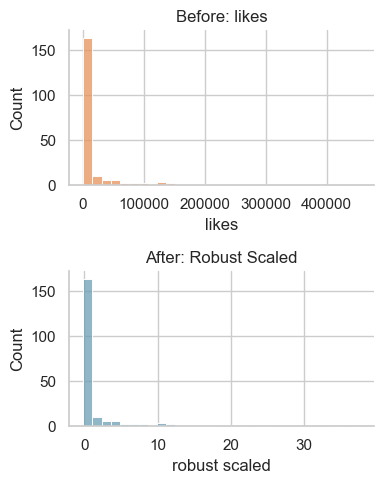

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["likes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: likes")
axes[0].set_xlabel("likes")

sns.histplot(df["likes_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

## Logarithmic Scaler

In [14]:
df["likes_log"] = np.log1p(df["likes"])

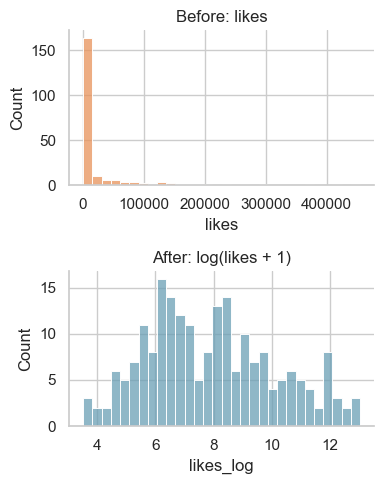

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["likes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: likes")
axes[0].set_xlabel("likes")

sns.histplot(df["likes_log"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(likes + 1)")
axes[1].set_xlabel("likes_log")

sns.despine()
plt.tight_layout()
plt.show()

## Binning

In [16]:
df["shares"].describe()

count      210.000000
mean      3947.052381
std       8731.782974
min          5.000000
25%         65.500000
50%        335.000000
75%       2243.250000
max      48004.000000
Name: shares, dtype: float64

/var/folders/gz/ks34dzcs0j5bsr2wvypj7fj80000gn/T/ipykernel_6842/224814739.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


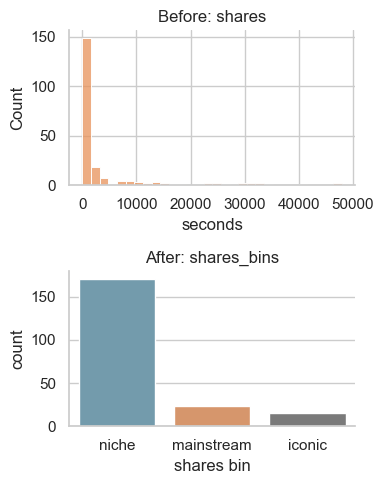

In [17]:
bins = [0, 4000, 20000, float("inf")]
labels = ["niche", "mainstream", "iconic"]

df["shares_bins"] = pd.cut(
    df["shares"],
    bins=bins,
    labels=labels
)

order = ["niche", "mainstream", "iconic"]
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["shares"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: shares")
axes[0].set_xlabel("seconds")

sns.countplot(data=df,
              x="shares_bins",
              order=order,
              palette=colors,
              ax=axes[1])
axes[1].set_title("After: shares_bins")
axes[1].set_xlabel("shares bin")
axes[1].set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

## Ordinal Encoding

In [18]:
encode = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df["channel_tier_encoded"] = encode.fit_transform(
    df[["channel_tier"]]
)

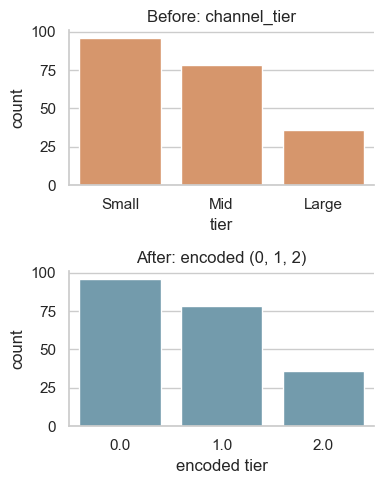

In [19]:

fig, axes = plt.subplots(2, 1, figsize=(4, 5))
order_str = ["Small", "Mid", "Large"]
sns.countplot(data=df,
              x="channel_tier",
              order=order_str,
              color="#e8925a",
              ax=axes[0])
axes[0].set_title("Before: channel_tier")
axes[0].set_xlabel("tier")

order_num = [0, 1, 2]
sns.countplot(data=df,
              x="channel_tier_encoded",
              color="#6a9fb5",
              ax=axes[1])
axes[1].set_title("After: encoded (0, 1, 2)")
axes[1].set_xlabel("encoded tier")

sns.despine()
plt.tight_layout()
plt.show()

## Retention Rate

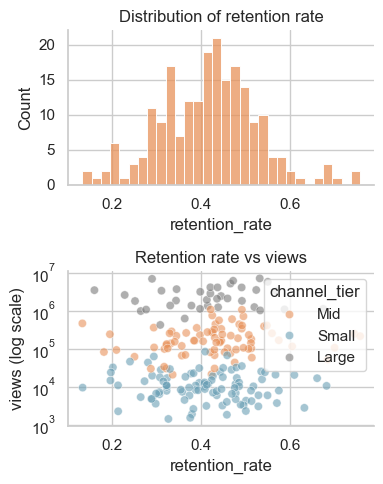

In [20]:
df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_minutes"])
).clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()

## Multi-Label Encoding

In [21]:
df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
